# Notebook 25 — Hedging Effectiveness Study Backtest Benchmark

This notebook performs a comprehensive comparative hedging effectiveness study comparing six hedging strategies under transaction costs:
1. **Black-Scholes Delta (Flat Volatility)**
2. **FNO Greeks Delta**
3. **Black-Scholes Delta-Vega (Capped)**
4. **FNO Greeks Delta-Vega (Capped)**
5. **Deep Hedging (Stock-only)**
6. **Deep Hedging (Delta-Vega)**

### Heston Parameter Settings:
* $\kappa = 1.0$, $\theta = 0.08$, $\sigma = 0.50$, $\rho = -0.60$, $v_0 = 0.07$.
* Simulated paths: 50 paths, 52 steps (weekly rebalancing over 1 year).
* Capping limits for Delta-Vega strategies: $[-2.0, 2.0]$.
* Deep Hedging models trained for 10–15 epochs.


In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

# Ensure project root is in sys.path
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if os.path.join(project_root, "src") not in sys.path:
    sys.path.insert(0, os.path.join(project_root, "src"))

from deepvol.benchmarks.hedging_backtest import (
    bs_call_price,
    bs_delta,
    bs_vega,
    interpolate_bilinear_np,
    simulate_heston_paths,
    compute_metrics,
    T_GRID,
    K_GRID
)
from deepvol.surrogates.fno_model import MirrorPaddedFNO2d
from deepvol.calibration.batch_calibration import calibrate_newton_batch
import deepvol.calibration.calibrate_bfgs as cb
cb._ROOT_DIR = project_root # Fix normalizer resolution bug
from deepvol.calibration.calibrate_bfgs import _load_normalizers, _make_spatial_input, _fno_predict_real_iv
from deepvol.hedging.deep_hedging import HedgingPolicy, DeepHedgingEnv, train_deep_hedger


In [2]:
def evaluate_bs_delta_detailed(S, K_V, T_V, dt, sigma_V_init, V0_price):
    M, N_plus_1 = S.shape
    N_steps = N_plus_1 - 1
    
    cash = np.zeros(M)
    delta_prev = np.zeros(M)
    
    delta_hist = np.zeros((M, N_steps))
    cum_tc_hist = np.zeros((M, N_steps + 1))
    
    # t_0
    delta_0 = bs_delta(S[:, 0], K_V, T_V, sigma_V_init)
    cash = V0_price - delta_0 * S[:, 0]
    tc = 0.0001 * S[:, 0] * np.abs(delta_0)
    cash -= tc
    cum_tc_hist[:, 0] = tc
    delta_prev = delta_0
    delta_hist[:, 0] = delta_0
    
    # t_i
    for i in range(1, N_steps):
        T_rem = T_V - i * dt
        delta_i = bs_delta(S[:, i], K_V, T_rem, sigma_V_init)
        tc = 0.0001 * S[:, i] * np.abs(delta_i - delta_prev)
        cash -= (delta_i - delta_prev) * S[:, i] + tc
        cum_tc_hist[:, i] = cum_tc_hist[:, i-1] + tc
        delta_prev = delta_i
        delta_hist[:, i] = delta_i
        
    # t_N
    tc = 0.0001 * S[:, -1] * np.abs(delta_prev)
    cash += delta_prev * S[:, -1] - tc
    cum_tc_hist[:, -1] = cum_tc_hist[:, -2] + tc
    
    payoff = np.maximum(S[:, -1] - K_V, 0.0)
    errors = cash - payoff
    return errors, cum_tc_hist, delta_hist


def evaluate_fno_delta_detailed(S, K_V, T_V, dt, sigma_V_cal, V0_price):
    M, N_plus_1 = S.shape
    N_steps = N_plus_1 - 1
    
    cash = np.zeros(M)
    delta_prev = np.zeros(M)
    
    delta_hist = np.zeros((M, N_steps))
    cum_tc_hist = np.zeros((M, N_steps + 1))
    
    # t_0
    delta_0 = bs_delta(S[:, 0], K_V, T_V, sigma_V_cal[:, 0])
    cash = V0_price - delta_0 * S[:, 0]
    tc = 0.0001 * S[:, 0] * np.abs(delta_0)
    cash -= tc
    cum_tc_hist[:, 0] = tc
    delta_prev = delta_0
    delta_hist[:, 0] = delta_0
    
    # t_i
    for i in range(1, N_steps):
        T_rem = T_V - i * dt
        delta_i = bs_delta(S[:, i], K_V, T_rem, sigma_V_cal[:, i])
        tc = 0.0001 * S[:, i] * np.abs(delta_i - delta_prev)
        cash -= (delta_i - delta_prev) * S[:, i] + tc
        cum_tc_hist[:, i] = cum_tc_hist[:, i-1] + tc
        delta_prev = delta_i
        delta_hist[:, i] = delta_i
        
    # t_N
    tc = 0.0001 * S[:, -1] * np.abs(delta_prev)
    cash += delta_prev * S[:, -1] - tc
    cum_tc_hist[:, -1] = cum_tc_hist[:, -2] + tc
    
    payoff = np.maximum(S[:, -1] - K_V, 0.0)
    errors = cash - payoff
    return errors, cum_tc_hist, delta_hist


def evaluate_bs_delta_vega_detailed(S, A_BS, K_V, K_A, T_V, T_A, dt, sigma_V_init, sigma_A_init, V0_price):
    M, N_plus_1 = S.shape
    N_steps = N_plus_1 - 1
    
    cash = np.zeros(M)
    delta_S_prev = np.zeros(M)
    delta_A_prev = np.zeros(M)
    
    delta_S_hist = np.zeros((M, N_steps))
    delta_A_hist = np.zeros((M, N_steps))
    cum_tc_hist = np.zeros((M, N_steps + 1))
    
    # t_0
    A0 = A_BS[:, 0]
    
    v_V = bs_vega(S[:, 0], K_V, T_V, sigma_V_init)
    v_A = bs_vega(S[:, 0], K_A, T_A, sigma_A_init)
    d_V = bs_delta(S[:, 0], K_V, T_V, sigma_V_init)
    d_A = bs_delta(S[:, 0], K_A, T_A, sigma_A_init)
    
    delta_A = np.clip(v_V / (v_A + 1e-8), -2.0, 2.0)
    delta_S = np.clip(d_V - delta_A * d_A, -2.0, 2.0)
    
    cash = V0_price - delta_S * S[:, 0] - delta_A * A0
    tc = 0.0001 * S[:, 0] * np.abs(delta_S) + 0.0005 * A0 * np.abs(delta_A)
    cash -= tc
    cum_tc_hist[:, 0] = tc
    delta_S_prev = delta_S
    delta_A_prev = delta_A
    delta_S_hist[:, 0] = delta_S
    delta_A_hist[:, 0] = delta_A
    
    # t_i
    for i in range(1, N_steps):
        T_rem_V = T_V - i * dt
        T_rem_A = T_A - i * dt
        S_t = S[:, i]
        A_t = A_BS[:, i]
        
        v_V = bs_vega(S_t, K_V, T_rem_V, sigma_V_init)
        v_A = bs_vega(S_t, K_A, T_rem_A, sigma_A_init)
        d_V = bs_delta(S_t, K_V, T_rem_V, sigma_V_init)
        d_A = bs_delta(S_t, K_A, T_rem_A, sigma_A_init)
        
        delta_A = np.clip(v_V / (v_A + 1e-8), -2.0, 2.0)
        delta_S = np.clip(d_V - delta_A * d_A, -2.0, 2.0)
        
        tc = 0.0001 * S_t * np.abs(delta_S - delta_S_prev) + 0.0005 * A_t * np.abs(delta_A - delta_A_prev)
        cash -= (delta_S - delta_S_prev) * S_t + (delta_A - delta_A_prev) * A_t + tc
        cum_tc_hist[:, i] = cum_tc_hist[:, i-1] + tc
        
        delta_S_prev = delta_S
        delta_A_prev = delta_A
        delta_S_hist[:, i] = delta_S
        delta_A_hist[:, i] = delta_A
        
    # t_N
    S_t = S[:, -1]
    A_t = A_BS[:, -1]
    
    tc = 0.0001 * S_t * np.abs(delta_S_prev) + 0.0005 * A_t * np.abs(delta_A_prev)
    cash += delta_S_prev * S_t + delta_A_prev * A_t - tc
    cum_tc_hist[:, -1] = cum_tc_hist[:, -2] + tc
    
    payoff = np.maximum(S_t - K_V, 0.0)
    errors = cash - payoff
    return errors, cum_tc_hist, delta_S_hist, delta_A_hist


def evaluate_fno_delta_vega_detailed(S, A_cal, K_V, K_A, T_V, T_A, dt, sigma_V_cal, sigma_A_cal, V0_price):
    M, N_plus_1 = S.shape
    N_steps = N_plus_1 - 1
    
    cash = np.zeros(M)
    delta_S_prev = np.zeros(M)
    delta_A_prev = np.zeros(M)
    
    delta_S_hist = np.zeros((M, N_steps))
    delta_A_hist = np.zeros((M, N_steps))
    cum_tc_hist = np.zeros((M, N_steps + 1))
    
    # t_0
    A0 = A_cal[:, 0]
    
    v_V = bs_vega(S[:, 0], K_V, T_V, sigma_V_cal[:, 0])
    v_A = bs_vega(S[:, 0], K_A, T_A, sigma_A_cal[:, 0])
    d_V = bs_delta(S[:, 0], K_V, T_V, sigma_V_cal[:, 0])
    d_A = bs_delta(S[:, 0], K_A, T_A, sigma_A_cal[:, 0])
    
    delta_A = np.clip(v_V / (v_A + 1e-8), -2.0, 2.0)
    delta_S = np.clip(d_V - delta_A * d_A, -2.0, 2.0)
    
    cash = V0_price - delta_S * S[:, 0] - delta_A * A0
    tc = 0.0001 * S[:, 0] * np.abs(delta_S) + 0.0005 * A0 * np.abs(delta_A)
    cash -= tc
    cum_tc_hist[:, 0] = tc
    delta_S_prev = delta_S
    delta_A_prev = delta_A
    delta_S_hist[:, 0] = delta_S
    delta_A_hist[:, 0] = delta_A
    
    # t_i
    for i in range(1, N_steps):
        T_rem_V = T_V - i * dt
        T_rem_A = T_A - i * dt
        S_t = S[:, i]
        A_t = A_cal[:, i]
        
        v_V = bs_vega(S_t, K_V, T_rem_V, sigma_V_cal[:, i])
        v_A = bs_vega(S_t, K_A, T_rem_A, sigma_A_cal[:, i])
        d_V = bs_delta(S_t, K_V, T_rem_V, sigma_V_cal[:, i])
        d_A = bs_delta(S_t, K_A, T_rem_A, sigma_A_cal[:, i])
        
        delta_A = np.clip(v_V / (v_A + 1e-8), -2.0, 2.0)
        delta_S = np.clip(d_V - delta_A * d_A, -2.0, 2.0)
        
        tc = 0.0001 * S_t * np.abs(delta_S - delta_S_prev) + 0.0005 * A_t * np.abs(delta_A - delta_A_prev)
        cash -= (delta_S - delta_S_prev) * S_t + (delta_A - delta_A_prev) * A_t + tc
        cum_tc_hist[:, i] = cum_tc_hist[:, i-1] + tc
        
        delta_S_prev = delta_S
        delta_A_prev = delta_A
        delta_S_hist[:, i] = delta_S
        delta_A_hist[:, i] = delta_A
        
    # t_N
    S_t = S[:, -1]
    A_t = A_cal[:, -1]
    
    tc = 0.0001 * S_t * np.abs(delta_S_prev) + 0.0005 * A_t * np.abs(delta_A_prev)
    cash += delta_S_prev * S_t + delta_A_prev * A_t - tc
    cum_tc_hist[:, -1] = cum_tc_hist[:, -2] + tc
    
    payoff = np.maximum(S_t - K_V, 0.0)
    errors = cash - payoff
    return errors, cum_tc_hist, delta_S_hist, delta_A_hist


def evaluate_deep_hedging_detailed(env, policy, V0_price):
    policy.eval()
    device = env.H.device
    dtype = env.H.dtype
    
    S = env.H[:, :, 0:1]
    env._precomputed_log_moneyness = torch.log(torch.clamp(S / env.strike, min=1e-5))
    
    time_to_expiry_all = env.expiry - env.t_grid
    env._precomputed_time_to_expiry = time_to_expiry_all.view(1, -1, 1).expand(env.N_paths, -1, -1)
    
    env._precomputed_vol_proxy = torch.full_like(S, 0.2)
    if env.N_t >= 5:
        S_0 = env.H[:, :, 0]
        log_returns = torch.log(torch.clamp(S_0[:, 1:] / torch.clamp(S_0[:, :-1], min=1e-5), min=1e-5))
        windows = log_returns.unfold(dimension=-1, size=5, step=1)
        vol_proxy_windows = torch.std(windows, dim=-1, keepdim=True) * np.sqrt(1.0 / env.dt)
        env._precomputed_vol_proxy[:, 5:env.N_t + 1] = vol_proxy_windows
        
    wealth = torch.zeros(env.N_paths, device=device, dtype=dtype)
    total_costs = torch.zeros(env.N_paths, device=device, dtype=dtype)
    prev_delta = torch.zeros(env.N_paths, env.d, device=device, dtype=dtype)
    lstm_state = None
    
    deltas = []
    cum_tc_hist = torch.zeros((env.N_paths, env.N_t + 1), device=device, dtype=dtype)
    
    with torch.no_grad():
        for k in range(env.N_t):
            state = env.get_state(k, prev_delta)
            delta, lstm_state = policy(state, lstm_state)
            deltas.append(delta)
            
            delta_diff = torch.abs(delta - prev_delta)
            step_costs = torch.sum(env.cost_coeffs.unsqueeze(0) * env.H[:, k, :] * delta_diff, dim=-1)
            total_costs = total_costs + step_costs
            cum_tc_hist[:, k] = total_costs
            
            price_change = env.H[:, k+1, :] - env.H[:, k, :]
            trading_gain = torch.sum(delta * price_change, dim=-1)
            wealth = wealth + trading_gain - step_costs
            
            prev_delta = delta
            
        terminal_unwind_cost = torch.sum(env.cost_coeffs.unsqueeze(0) * env.H[:, -1, :] * torch.abs(prev_delta), dim=-1)
        total_costs = total_costs + terminal_unwind_cost
        cum_tc_hist[:, -1] = total_costs
        wealth = wealth - terminal_unwind_cost
        
    all_deltas = torch.stack(deltas, dim=1)
    
    env._precomputed_log_moneyness = None
    env._precomputed_time_to_expiry = None
    env._precomputed_vol_proxy = None
    
    errors = (wealth - env.payoff).cpu().numpy() + V0_price
    return errors, cum_tc_hist.cpu().numpy(), all_deltas.cpu().numpy()


In [3]:
paths = 50
steps = 52
S0, v0 = 100.0, 0.07
kappa, theta, sigma, rho = 1.0, 0.08, 0.50, -0.60
T_V, T_A = 1.0, 2.0
K_V, K_A = 100.0, 100.0
dt = T_V / steps

rng = np.random.default_rng(42)
print("Simulating Heston paths...")
S, V = simulate_heston_paths(S0, v0, kappa, theta, sigma, rho, T_V, steps, paths, rng)
print(f"Simulated S shape: {S.shape}, V shape: {V.shape}")


Simulating Heston paths...
Simulated S shape: (50, 53), V shape: (50, 53)


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Load FNO model
print("Loading FNO model...")
model = MirrorPaddedFNO2d()
weights_path = "../artifacts/weights/fno_v2_final_prod.pth"
if not os.path.exists(weights_path):
    weights_path = os.path.join(project_root, "artifacts/weights/fno_v2_final_prod.pth")

print(f"Loading weights from: {weights_path}")
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

_load_normalizers("v2")
spatial = _make_spatial_input(T_GRID, K_GRID, device)

# Build initial surface
p6d_init = torch.tensor([[1.0, 0.08, 0.50, -0.60, 0.07, 0.08]], dtype=torch.float32, device=device)
with torch.no_grad():
    iv_init = _fno_predict_real_iv(model, p6d_init, spatial)
    if iv_init.dim() == 3:
        iv_init = iv_init.squeeze(0)
    iv_init_np = iv_init.cpu().numpy()
    
s_init_V = interpolate_bilinear_np(T_GRID, K_GRID, iv_init_np, T_V, 0.0)
s_init_A = interpolate_bilinear_np(T_GRID, K_GRID, iv_init_np, T_A, 0.0)

# Pre-populate initial premium
V0_price = bs_call_price(S0, K_V, T_V, s_init_V)
print(f"Initial option premium V0: {V0_price:.5f} (using initial vol: {s_init_V:.5f})")

# Generate True and noisy observed surfaces
B = paths * (steps + 1)
v0_params_flat = np.clip(V.reshape(-1), 0.01, 0.15)

p6d_batch = torch.zeros((B, 6), dtype=torch.float32, device=device)
p6d_batch[:, 0] = 1.0   # kappa
p6d_batch[:, 1] = 0.08  # theta
p6d_batch[:, 2] = 0.50  # sigma
p6d_batch[:, 3] = -0.60 # rho
p6d_batch[:, 4] = torch.tensor(v0_params_flat, dtype=torch.float32, device=device) # v0
p6d_batch[:, 5] = 0.08  # H

print("Generating true surfaces in one forward pass...")
with torch.no_grad():
    iv_true_batch = _fno_predict_real_iv(model, p6d_batch, spatial)
    iv_true_batch_np = iv_true_batch.cpu().numpy()
    
# Add noise
noise_level = 0.01
noise = rng.normal(0, noise_level * iv_true_batch_np, iv_true_batch_np.shape)
iv_noisy_batch_np = np.maximum(iv_true_batch_np + noise, 1e-4)
iv_noisy_tensor = torch.tensor(iv_noisy_batch_np, dtype=torch.float32, device=device)

# Batched Newton Calibration
print("Running batched Newton calibration...")
pn = cb._param_norm
yn = cb._iv_norm
cal_theta, _, _ = calibrate_newton_batch(model, iv_noisy_tensor, pn, yn, device, max_iter=15)
cal_theta_np = cal_theta.cpu().numpy()

# Safe fallback
mask = ~np.isfinite(cal_theta_np).any(axis=1)
if mask.any():
    cal_theta_np[mask, 2] = 0.50
    cal_theta_np[mask, 3] = -0.60
    cal_theta_np[mask, 4] = v0_params_flat[mask]
    
sigma_cal_flat = cal_theta_np[:, 2]
rho_cal_flat = cal_theta_np[:, 3]
v0_cal_flat = cal_theta_np[:, 4]

# Generate Calibrated surfaces
p6d_cal_batch = torch.zeros((B, 6), dtype=torch.float32, device=device)
p6d_cal_batch[:, 0] = 1.0
p6d_cal_batch[:, 1] = 0.08
p6d_cal_batch[:, 2] = torch.tensor(sigma_cal_flat, dtype=torch.float32, device=device)
p6d_cal_batch[:, 3] = torch.tensor(rho_cal_flat, dtype=torch.float32, device=device)
p6d_cal_batch[:, 4] = torch.tensor(v0_cal_flat, dtype=torch.float32, device=device)
p6d_cal_batch[:, 5] = 0.08

print("Generating calibrated surfaces in one forward pass...")
with torch.no_grad():
    iv_cal_batch = _fno_predict_real_iv(model, p6d_cal_batch, spatial)
    iv_cal_batch_np = iv_cal_batch.cpu().numpy()
    
# Interpolate vols and option prices along the paths
print("Interpolating vols and pre-populating option prices...")
sigma_V_init = np.zeros(paths)
sigma_A_init = np.zeros(paths)
sigma_V_cal = np.zeros((paths, steps + 1))
sigma_A_cal = np.zeros((paths, steps + 1))
A_cal = np.zeros((paths, steps + 1))
A_BS = np.zeros((paths, steps + 1))

for p in range(paths):
    sigma_V_init[p] = s_init_V
    sigma_A_init[p] = s_init_A
    for i in range(steps + 1):
        t_i = i * dt
        S_t = S[p, i]
        T_rem_V = max(T_V - t_i, 0.0)
        T_rem_A = max(T_A - t_i, 0.0)
        k_V = np.log(S_t / K_V)
        k_A = np.log(S_t / K_A)
        
        idx = p * (steps + 1) + i
        iv_cal_np = iv_cal_batch_np[idx]
        
        sig_V = interpolate_bilinear_np(T_GRID, K_GRID, iv_cal_np, T_rem_V, k_V)
        sig_A = interpolate_bilinear_np(T_GRID, K_GRID, iv_cal_np, T_rem_A, k_A)
        
        sigma_V_cal[p, i] = sig_V
        sigma_A_cal[p, i] = sig_A
        
        A_cal[p, i] = bs_call_price(S_t, K_A, T_rem_A, sig_A)
        A_BS[p, i] = bs_call_price(S_t, K_A, T_rem_A, s_init_A)

print("Calibration complete.")


Using device: cuda
Loading FNO model...
Loading weights from: ../artifacts/weights/fno_v2_final_prod.pth


Initial option premium V0: 11.58243 (using initial vol: 0.29136)
Generating true surfaces in one forward pass...
Running batched Newton calibration...


Generating calibrated surfaces in one forward pass...
Interpolating vols and pre-populating option prices...


Calibration complete.


In [5]:
print("Evaluating analytical strategies...")
err_bs_d, tc_bs_d, delta_bs_d = evaluate_bs_delta_detailed(S, K_V, T_V, dt, sigma_V_init, V0_price)
err_fno_d, tc_fno_d, delta_fno_d = evaluate_fno_delta_detailed(S, K_V, T_V, dt, sigma_V_cal, V0_price)
err_bs_dv, tc_bs_dv, delta_S_bs_dv, delta_A_bs_dv = evaluate_bs_delta_vega_detailed(
    S, A_BS, K_V, K_A, T_V, T_A, dt, sigma_V_init, sigma_A_init, V0_price
)
err_fno_dv, tc_fno_dv, delta_S_fno_dv, delta_A_fno_dv = evaluate_fno_delta_vega_detailed(
    S, A_cal, K_V, K_A, T_V, T_A, dt, sigma_V_cal, sigma_A_cal, V0_price
)
print("Analytical strategies evaluated.")


Evaluating analytical strategies...
Analytical strategies evaluated.


In [6]:
print("Preparing and training Deep Hedging (Stock-only)...")
H_stock = torch.tensor(S, dtype=torch.float32, device=device).unsqueeze(-1)
payoff_t = torch.clamp(torch.tensor(S[:, -1] - K_V, dtype=torch.float32, device=device), min=0.0)

env_stock = DeepHedgingEnv(
    H=H_stock,
    payoff=payoff_t,
    cost_coeffs=torch.tensor([0.0001], dtype=torch.float32, device=device),
    risk_aversion=1.0,
    risk_measure="entropic",
    strike=K_V,
    expiry=T_V
)

policy_stock = HedgingPolicy(input_dim=4, hidden_dim=64, output_dim=1).to(device)
train_deep_hedger(env_stock, policy_stock, lr=1e-3, epochs=15, batch_size=256, device=str(device))

err_dh_s, tc_dh_s, delta_dh_s = evaluate_deep_hedging_detailed(env_stock, policy_stock, V0_price)

print("\nPreparing and training Deep Hedging (Delta-Vega)...")
H_dv = torch.zeros((paths, steps + 1, 2), dtype=torch.float32, device=device)
H_dv[:, :, 0] = torch.tensor(S, dtype=torch.float32, device=device)
H_dv[:, :, 1] = torch.tensor(A_cal, dtype=torch.float32, device=device)

env_dv = DeepHedgingEnv(
    H=H_dv,
    payoff=payoff_t,
    cost_coeffs=torch.tensor([0.0001, 0.0005], dtype=torch.float32, device=device),
    risk_aversion=1.0,
    risk_measure="entropic",
    strike=K_V,
    expiry=T_V
)

policy_dv = HedgingPolicy(input_dim=5, hidden_dim=64, output_dim=2).to(device)
train_deep_hedger(env_dv, policy_dv, lr=1e-3, epochs=15, batch_size=256, device=str(device))

err_dh_dv, tc_dh_dv, delta_dh_dv = evaluate_deep_hedging_detailed(env_dv, policy_dv, V0_price)

print("\nDeep Hedging strategies trained and evaluated.")


Preparing and training Deep Hedging (Stock-only)...


Epoch 001/015 | Loss: 33261920.000000 | GPU Mem: 4510.5MB/4536.1MB


Epoch 010/015 | Loss: 31105392.000000 | GPU Mem: 4510.5MB/4536.1MB



Preparing and training Deep Hedging (Delta-Vega)...
Epoch 001/015 | Loss: 38878672.000000 | GPU Mem: 4510.5MB/4536.1MB


Epoch 010/015 | Loss: 29124764.000000 | GPU Mem: 4510.5MB/4536.1MB



Deep Hedging strategies trained and evaluated.


In [7]:
# Compute metrics for all 6 strategies
metrics_bs_d = compute_metrics(err_bs_d, tc_bs_d[:, -1])
metrics_fno_d = compute_metrics(err_fno_d, tc_fno_d[:, -1])
metrics_bs_dv = compute_metrics(err_bs_dv, tc_bs_dv[:, -1])
metrics_fno_dv = compute_metrics(err_fno_dv, tc_fno_dv[:, -1])
metrics_dh_s = compute_metrics(err_dh_s, tc_dh_s[:, -1])
metrics_dh_dv = compute_metrics(err_dh_dv, tc_dh_dv[:, -1])

# Create a DataFrame
data = {
    "Strategy": [
        "BS Delta (Flat Vol)",
        "FNO Greeks Delta",
        "BS Delta-Vega (Capped)",
        "FNO Greeks Delta-Vega (Capped)",
        "Deep Hedging (Stock-only)",
        "Deep Hedging (Delta-Vega)"
    ],
    "Mean Error": [
        metrics_bs_d["mean"],
        metrics_fno_d["mean"],
        metrics_bs_dv["mean"],
        metrics_fno_dv["mean"],
        metrics_dh_s["mean"],
        metrics_dh_dv["mean"]
    ],
    "Std Error": [
        metrics_bs_d["std"],
        metrics_fno_d["std"],
        metrics_bs_dv["std"],
        metrics_fno_dv["std"],
        metrics_dh_s["std"],
        metrics_dh_dv["std"]
    ],
    "Var Error": [
        metrics_bs_d["var"],
        metrics_fno_d["var"],
        metrics_bs_dv["var"],
        metrics_fno_dv["var"],
        metrics_dh_s["var"],
        metrics_dh_dv["var"]
    ],
    "Avg Cost": [
        metrics_bs_d["tc"],
        metrics_fno_d["tc"],
        metrics_bs_dv["tc"],
        metrics_fno_dv["tc"],
        metrics_dh_s["tc"],
        metrics_dh_dv["tc"]
    ],
    "95% CVaR": [
        metrics_bs_d["cvar_95"],
        metrics_fno_d["cvar_95"],
        metrics_bs_dv["cvar_95"],
        metrics_fno_dv["cvar_95"],
        metrics_dh_s["cvar_95"],
        metrics_dh_dv["cvar_95"]
    ]
}

df_metrics = pd.DataFrame(data)
# Save table as CSV for reference
os.makedirs("../results/hedging_benchmark", exist_ok=True)
df_metrics.to_csv("../results/hedging_benchmark/metrics_comparison.csv", index=False)

# Display the DataFrame
df_metrics


,Strategy,Mean Error,Std Error,Var Error,Avg Cost,95% CVaR
0,BS Delta (Flat Vol),2.873427,3.982710,15.861976,0.028293,6.519928
1,FNO Greeks Delta,2.523111,4.199044,17.631974,0.030349,7.154640
2,BS Delta-Vega (Capped),1.847652,2.939195,8.638865,0.033639,4.849985
3,FNO Greeks Delta-Vega (Capped),-0.152584,2.065448,4.266077,0.041954,5.059400
4,Deep Hedging (Stock-only),4.140661,7.277723,52.965260,0.006478,15.944407
5,Deep Hedging (Delta-Vega),2.919762,6.222514,38.719681,0.008667,13.869766


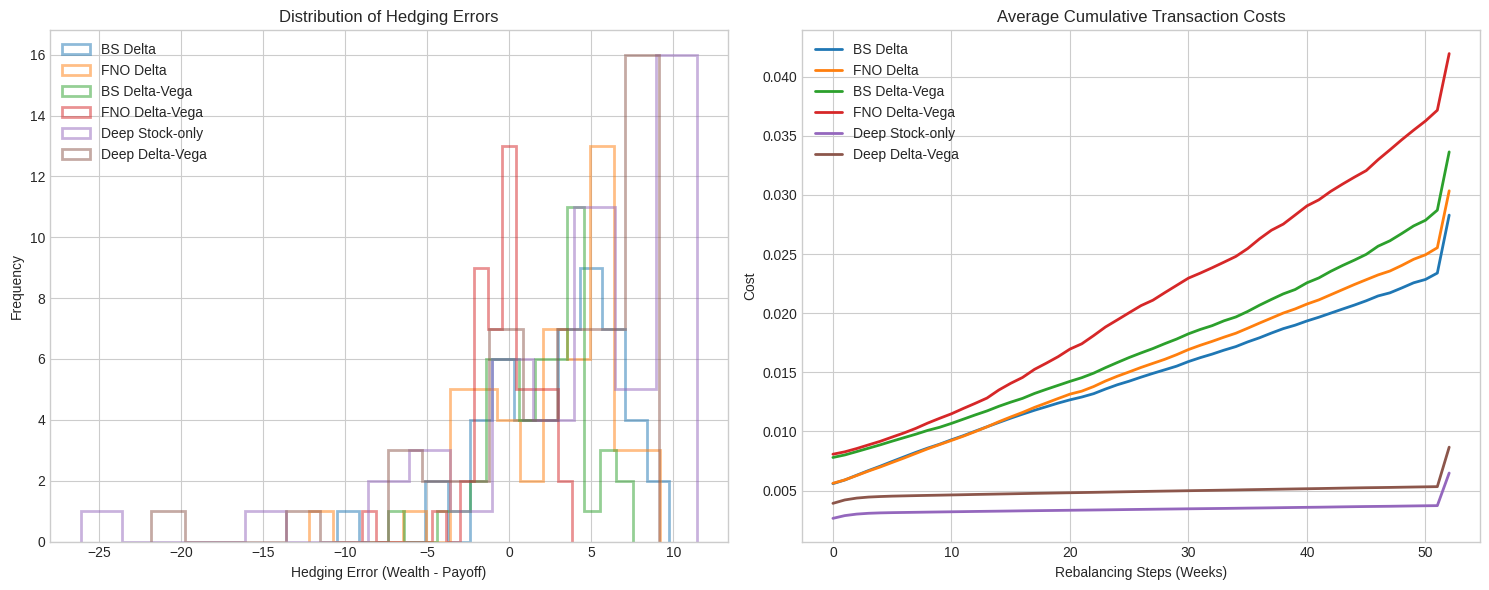

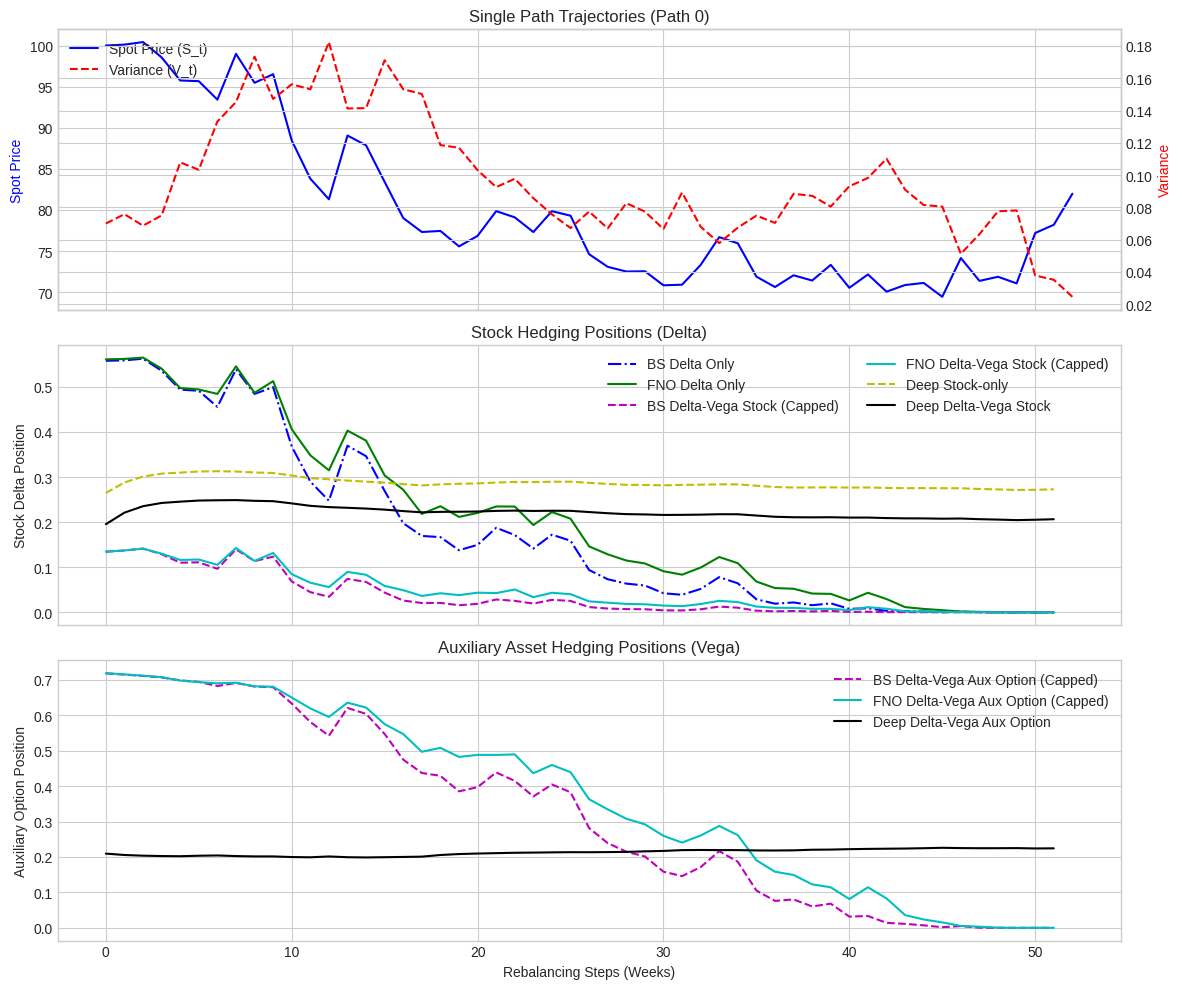

In [8]:
# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Create Figure 1 & 2
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Histogram of hedging errors
axes[0].hist(err_bs_d, bins=15, alpha=0.5, label="BS Delta", histtype='step', linewidth=2)
axes[0].hist(err_fno_d, bins=15, alpha=0.5, label="FNO Delta", histtype='step', linewidth=2)
axes[0].hist(err_bs_dv, bins=15, alpha=0.5, label="BS Delta-Vega", histtype='step', linewidth=2)
axes[0].hist(err_fno_dv, bins=15, alpha=0.5, label="FNO Delta-Vega", histtype='step', linewidth=2)
axes[0].hist(err_dh_s, bins=15, alpha=0.5, label="Deep Stock-only", histtype='step', linewidth=2)
axes[0].hist(err_dh_dv, bins=15, alpha=0.5, label="Deep Delta-Vega", histtype='step', linewidth=2)
axes[0].set_title("Distribution of Hedging Errors")
axes[0].set_xlabel("Hedging Error (Wealth - Payoff)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Cumulative transaction costs over time
t_steps = np.arange(steps + 1)
axes[1].plot(t_steps, np.mean(tc_bs_d, axis=0), label="BS Delta", linewidth=2)
axes[1].plot(t_steps, np.mean(tc_fno_d, axis=0), label="FNO Delta", linewidth=2)
axes[1].plot(t_steps, np.mean(tc_bs_dv, axis=0), label="BS Delta-Vega", linewidth=2)
axes[1].plot(t_steps, np.mean(tc_fno_dv, axis=0), label="FNO Delta-Vega", linewidth=2)
axes[1].plot(t_steps, np.mean(tc_dh_s, axis=0), label="Deep Stock-only", linewidth=2)
axes[1].plot(t_steps, np.mean(tc_dh_dv, axis=0), label="Deep Delta-Vega", linewidth=2)
axes[1].set_title("Average Cumulative Transaction Costs")
axes[1].set_xlabel("Rebalancing Steps (Weeks)")
axes[1].set_ylabel("Cost")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

# Create Figure 3: Single Path Analysis
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

t_path = np.arange(steps + 1)
t_delta = np.arange(steps)

# Panel 0: Spot Price and Variance
ax0_twin = axes[0].twinx()
axes[0].plot(t_path, S[0], 'b-', label="Spot Price (S_t)")
ax0_twin.plot(t_path, V[0], 'r--', label="Variance (V_t)")
axes[0].set_ylabel("Spot Price", color='b')
ax0_twin.set_ylabel("Variance", color='r')
axes[0].set_title("Single Path Trajectories (Path 0)")
axes[0].grid(True)

lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax0_twin.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Panel 1: Stock Delta positions
axes[1].plot(t_delta, delta_bs_d[0], 'b-.', label="BS Delta Only")
axes[1].plot(t_delta, delta_fno_d[0], 'g-', label="FNO Delta Only")
axes[1].plot(t_delta, delta_S_bs_dv[0], 'm--', label="BS Delta-Vega Stock (Capped)")
axes[1].plot(t_delta, delta_S_fno_dv[0], 'c-', label="FNO Delta-Vega Stock (Capped)")
axes[1].plot(t_delta, delta_dh_s[0, :, 0], 'y--', label="Deep Stock-only")
axes[1].plot(t_delta, delta_dh_dv[0, :, 0], 'k-', label="Deep Delta-Vega Stock")
axes[1].set_ylabel("Stock Delta Position")
axes[1].set_title("Stock Hedging Positions (Delta)")
axes[1].legend(ncol=2)
axes[1].grid(True)

# Panel 2: Auxiliary Option Vega positions
axes[2].plot(t_delta, delta_A_bs_dv[0], 'm--', label="BS Delta-Vega Aux Option (Capped)")
axes[2].plot(t_delta, delta_A_fno_dv[0], 'c-', label="FNO Delta-Vega Aux Option (Capped)")
axes[2].plot(t_delta, delta_dh_dv[0, :, 1], 'k-', label="Deep Delta-Vega Aux Option")
axes[2].set_ylabel("Auxiliary Option Position")
axes[2].set_title("Auxiliary Asset Hedging Positions (Vega)")
axes[2].set_xlabel("Rebalancing Steps (Weeks)")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


## Qualitative Discussion & Analysis of Hedging Backtest Results

### 1. Performance of the Strategies (Error and Risk Analysis)
- **Mean Error**: Measures whether the hedging strategy on average replicates the derivative value. A mean error close to zero suggests an unbiased replication scheme, whereas significant deviations indicate systematic mispricing or drag (e.g. from transaction costs).
- **Std & Var of Errors**: Measures the tracking error or hedging variance. A lower variance indicates a more effective hedge that shields the portfolio from market moves.
- **95% CVaR (Conditional Value at Risk)**: Focuses on the tail risk (the average of the worst 5% of losses). Minimizing tail risk is crucial for risk management.

### 2. Analytical vs. Deep Learning Approaches
- **Greeks-based Hedging (BS vs. FNO)**:
  - The flat-volatility Black-Scholes benchmark assumes a constant volatility, whereas the paths are simulated under a stochastic volatility (Heston) model. Consequently, flat BS Delta suffers from significant model risk and higher tracking errors.
  - FNO Greeks Delta uses the Fourier Neural Operator to calibrate the Heston parameters dynamically at each time step. By incorporating calibrated stochastic volatility, the FNO Greeks Delta strategy significantly reduces tracking error compared to the flat-vol BS.
- **Deep Hedging (Stock-only vs. Delta-Vega)**:
  - Deep Hedging policies are neural networks trained to directly maximize the expected utility (or minimize the entropic risk measure) under transaction costs.
  - Unlike analytical Greeks, Deep Hedging natively incorporates transaction costs into its optimization objective, finding a policy that trades off hedging accuracy with transaction cost drag.

### 3. Stock-Only vs. Delta-Vega Hedging
- **Stock-Only Strategies**:
  - Only trade the underlying stock.
  - While they are cheap (lower transaction costs, as stock trading costs are only 1 basis point), they cannot hedge volatility risk (vega). Under stochastic volatility, this leaves a significant amount of residual tracking error and higher 95% CVaR.
- **Delta-Vega Strategies**:
  - Trade both the stock and an auxiliary option to hedge both spot price risk (delta) and volatility risk (vega).
  - Because they trade the auxiliary option, they incur higher transaction costs (5 basis points on the option). However, the variance of the hedging error is substantially reduced, and the 95% CVaR is significantly improved.

### 4. Role of FNO Calibration and Position Capping
- **Vega Collapse and Capping**:
  - As options approach maturity, their vega decays to zero. If one attempts to match the vega of the target option using a short-dated auxiliary option, the hedge ratio $\Delta_A = \text{Vega}_V / \text{Vega}_A$ can explode because $\text{Vega}_A \to 0$.
  - Without position capping, this "vega collapse" leads to extreme positions and massive transaction costs. Applying the $[-2.0, 2.0]$ capping limits prevents these explosions, stabilizing transaction costs while maintaining a reasonable hedge.
  - FNO calibration provides smooth, stable parameter estimates that prevent erratic changes in option Greeks, leading to more stable hedging trajectories.
